# Singapore HDB Resale Price Drivers

## Objective

Investigate how key property characteristics are associated with HDB resale prices.

In [1]:
from pathlib import Path

PROJECT_ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data").is_dir() and (path / "notebooks").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from inside the project directory.")

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "hdb_resale_clean.csv")

df["month"] = pd.to_datetime(df["month"])

df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,quarter,price_per_sqm,flat_age,storey_lower,storey_upper,storey_midpoint,remaining_lease_years,remaining_lease_extra_months,remaining_lease_months,remaining_lease_years_numeric
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,...,2017Q1,5272.73,38,10,12,11.0,61,4,736,61.33
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,...,2017Q1,3731.34,39,1,3,2.0,60,7,727,60.58
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,2017Q1,3910.45,37,1,3,2.0,62,5,749,62.42
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,...,2017Q1,3897.06,37,4,6,5.0,62,1,745,62.08
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,2017Q1,3955.22,37,1,3,2.0,62,5,749,62.42


## 1. Floor Area and Resale Price

In [2]:
df[["floor_area_sqm", "resale_price"]].corr()

,floor_area_sqm,resale_price
floor_area_sqm,1.00000,0.56338
resale_price,0.56338,1.00000


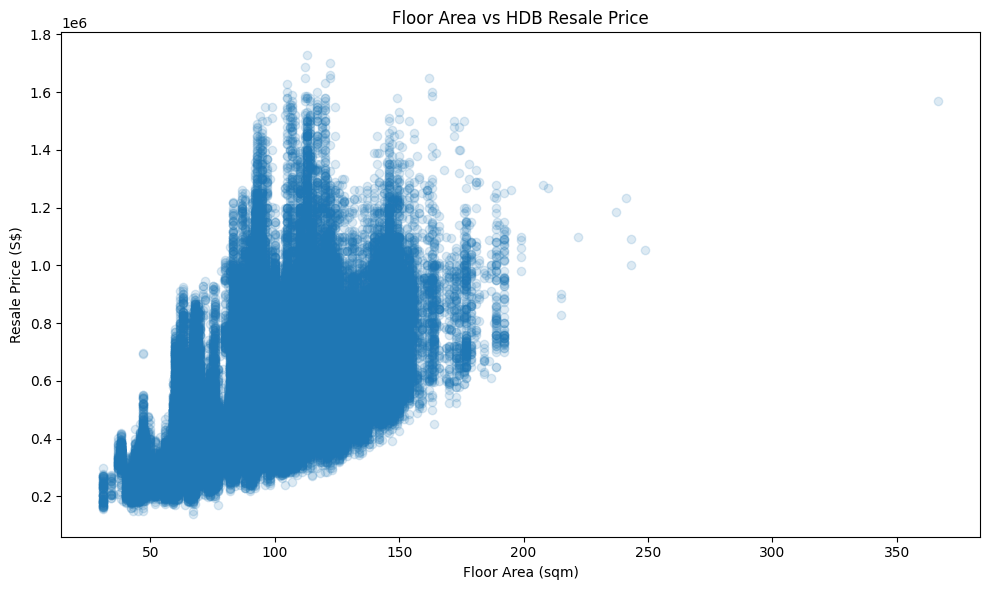

In [3]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["floor_area_sqm"],
    df["resale_price"],
    alpha=0.15
)

plt.title("Floor Area vs HDB Resale Price")
plt.xlabel("Floor Area (sqm)")
plt.ylabel("Resale Price (S$)")

plt.tight_layout()
plt.show()

In [4]:
df["floor_area_band"] = pd.cut(
    df["floor_area_sqm"],
    bins=[0, 60, 80, 100, 120, 150, float("inf")],
    labels=[
        "<60",
        "60–79",
        "80–99",
        "100–119",
        "120–149",
        "150+"
    ]
)

In [5]:
area_price = (
    df.groupby("floor_area_band", observed=False)["resale_price"]
    .median()
    .reset_index()
)

area_price

,floor_area_band,resale_price
0,<60,310000.0
1,60–79,366000.0
2,80–99,518000.0
3,100–119,552888.0
4,120–149,640000.0
5,150+,810000.0


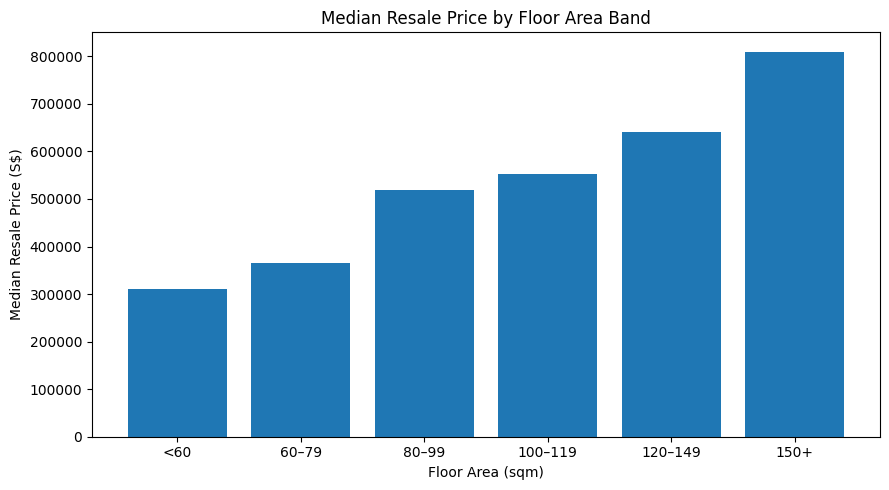

In [6]:
plt.figure(figsize=(9, 5))

plt.bar(
    area_price["floor_area_band"].astype(str),
    area_price["resale_price"]
)

plt.title("Median Resale Price by Floor Area Band")
plt.xlabel("Floor Area (sqm)")
plt.ylabel("Median Resale Price (S$)")

plt.tight_layout()
plt.show()

## 2. Remaining Lease and Resale Price

In [7]:
df[
    ["remaining_lease_years_numeric", "resale_price"]
].corr()

,remaining_lease_years_numeric,resale_price
remaining_lease_years_numeric,1.000000,0.300788
resale_price,0.300788,1.000000


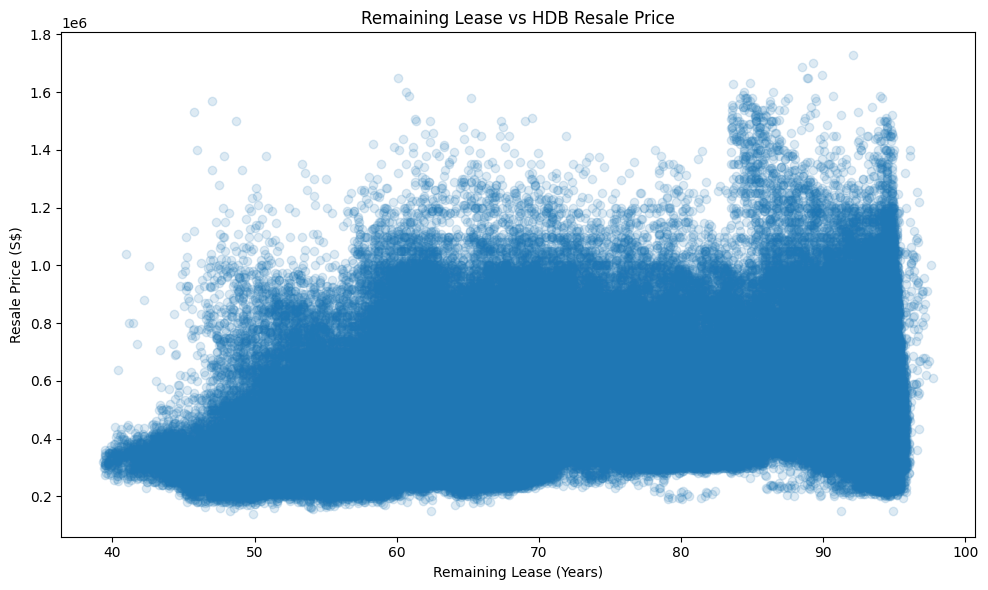

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["remaining_lease_years_numeric"],
    df["resale_price"],
    alpha=0.15
)

plt.title("Remaining Lease vs HDB Resale Price")
plt.xlabel("Remaining Lease (Years)")
plt.ylabel("Resale Price (S$)")

plt.tight_layout()
plt.show()

In [9]:
df["lease_band"] = pd.cut(
    df["remaining_lease_years_numeric"],
    bins=[0, 50, 60, 70, 80, 90, 100],
    labels=[
        "<50",
        "50–59",
        "60–69",
        "70–79",
        "80–89",
        "90+"
    ],
    right=False
)

In [10]:
lease_price = (
    df.groupby("lease_band", observed=False)["resale_price"]
    .median()
    .reset_index()
)

lease_price

,lease_band,resale_price
0,<50,338000.0
1,50–59,415000.0
2,60–69,455000.0
3,70–79,555000.0
4,80–89,535000.0
5,90+,565888.0


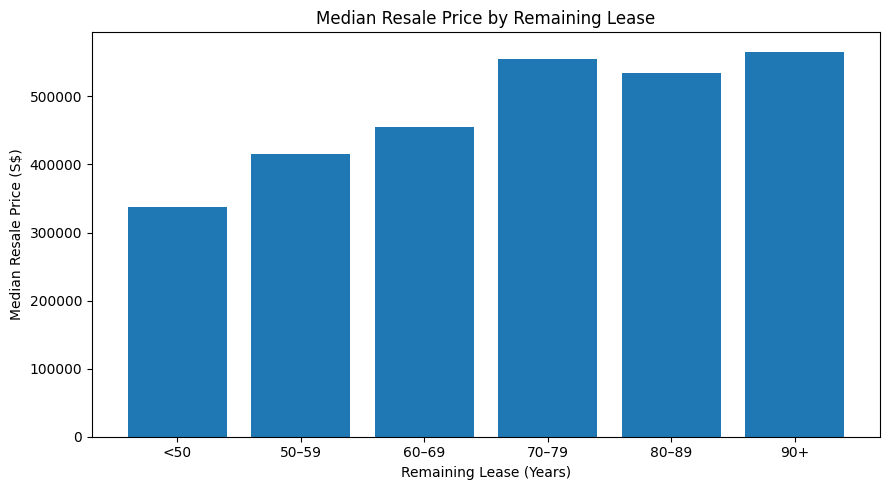

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(
    lease_price["lease_band"].astype(str),
    lease_price["resale_price"]
)

plt.title("Median Resale Price by Remaining Lease")
plt.xlabel("Remaining Lease (Years)")
plt.ylabel("Median Resale Price (S$)")

plt.tight_layout()
plt.show()

## 3. Storey and Resale Price

In [13]:
df[
    ["storey_midpoint", "resale_price"]
].corr()

,storey_midpoint,resale_price
storey_midpoint,1.00000,0.34157
resale_price,0.34157,1.00000


In [14]:
storey_price = (
    df.groupby("storey_range")["resale_price"]
    .median()
    .reset_index()
)

In [15]:
storey_price["storey_midpoint"] = (
    storey_price["storey_range"]
    .str.split(" TO ")
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2)
)

storey_price = storey_price.sort_values("storey_midpoint")

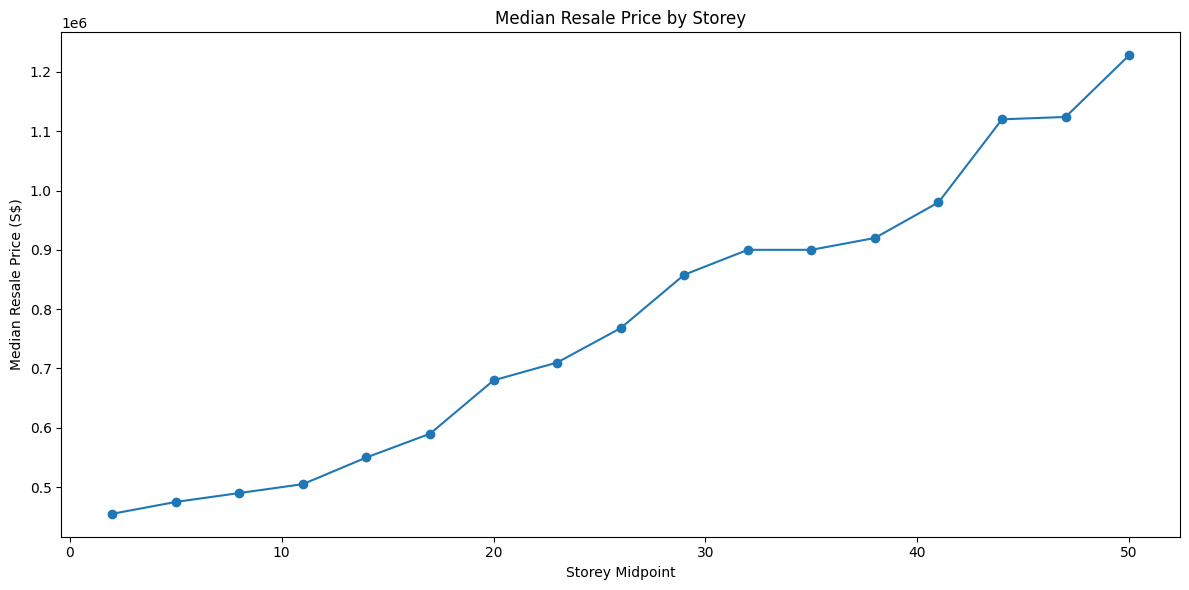

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    storey_price["storey_midpoint"],
    storey_price["resale_price"],
    marker="o"
)

plt.title("Median Resale Price by Storey")
plt.xlabel("Storey Midpoint")
plt.ylabel("Median Resale Price (S$)")

plt.tight_layout()
plt.show()

## 4. Town and Resale Price

In [17]:
town_price = (
    df.groupby("town")["resale_price"]
    .median()
    .reset_index()
    .sort_values("resale_price", ascending=False)
)

town_price.head(10)

,town,resale_price
6,BUKIT TIMAH,784000.0
2,BISHAN,700000.0
18,QUEENSTOWN,675000.0
4,BUKIT MERAH,660000.0
16,PASIR RIS,580000.0
7,CENTRAL AREA,575000.0
14,KALLANG/WHAMPOA,571784.0
22,TAMPINES,550000.0
21,SERANGOON,535000.0
17,PUNGGOL,535000.0


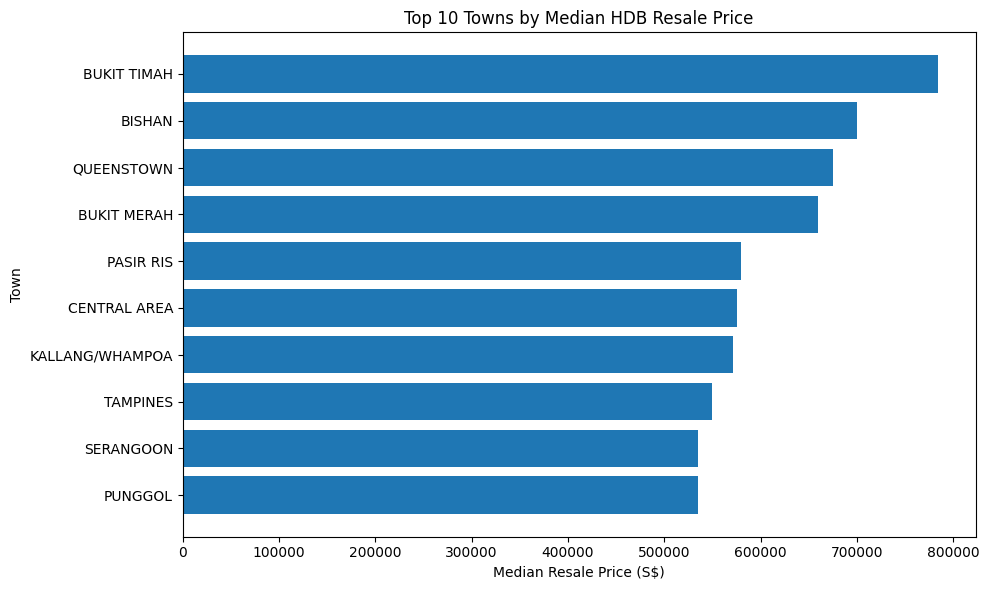

In [18]:
top10_town_price = town_price.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_town_price["town"],
    top10_town_price["resale_price"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Towns by Median HDB Resale Price")
plt.xlabel("Median Resale Price (S$)")
plt.ylabel("Town")

plt.tight_layout()
plt.show()

## 5. Flat Type and Resale Price

In [19]:
flat_type_price = (
    df.groupby("flat_type")["resale_price"]
    .median()
    .reset_index()
    .sort_values("resale_price")
)

flat_type_price

,flat_type,resale_price
0,1 ROOM,212500.0
1,2 ROOM,313000.0
2,3 ROOM,360000.0
3,4 ROOM,510000.0
4,5 ROOM,612000.0
5,EXECUTIVE,728000.0
6,MULTI-GENERATION,846500.0


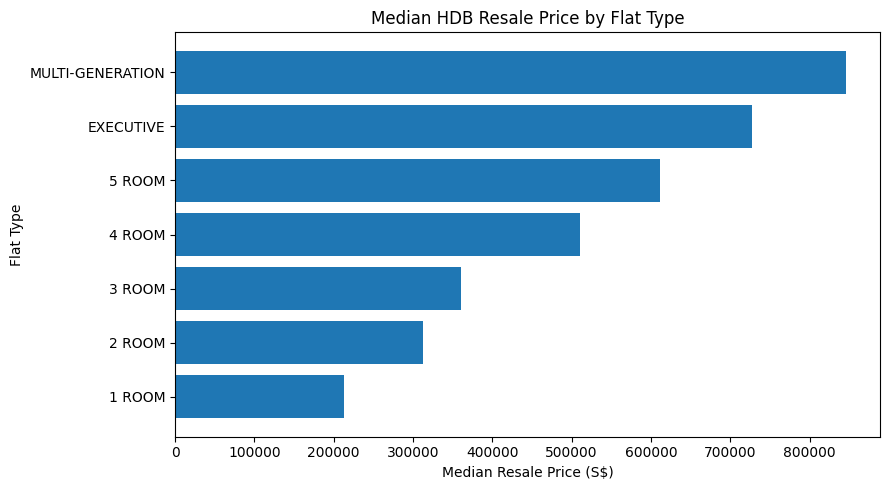

In [20]:
plt.figure(figsize=(9, 5))

plt.barh(
    flat_type_price["flat_type"],
    flat_type_price["resale_price"]
)

plt.title("Median HDB Resale Price by Flat Type")
plt.xlabel("Median Resale Price (S$)")
plt.ylabel("Flat Type")

plt.tight_layout()
plt.show()

## 6. Numeric Correlations

In [ ]:
numeric_vars = [
    "resale_price",
    "floor_area_sqm",
    "remaining_lease_years_numeric",
    "storey_midpoint",
    "flat_age"
]

correlation_matrix = df[numeric_vars].corr()

correlation_matrix